# 11. Error Analysis — Best Model (from `3_evaluate`)

`3_evaluate` 와 **동일한 데이터 경로**(`infer.predict_all_from_weights` — 저장 가중치 → OOS 예측 재현)로
**최선 모델**(fair R² 최대)을 자동 선택해 stage-2 오차가 어디서·왜 생기는지 분석.
프레임워크: `fair = MC_hat(stage1) + recent_margin + residual(stage2)`, walk-forward OOS.
**모든 그래프는 영문(figure text is English only).**

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from util import utils, file_manager as fm
from util.metric import metrics, stage_r2
from module import data, infer
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 4.8), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold", "font.family": "DejaVu Sans"})
FACE = 10000; IMG = fm.IMAGE
BLU, ORG, DK, RED, GRN = "#1f6f9c", "#e07a5f", "#1c4a5f", "#c0392b", "#2a9d8f"
cfg = utils.load_config(); D = data.load(cfg)
preds = infer.predict_all_from_weights(D, cfg)                       # 저장 가중치 → 예측 (3_evaluate 와 동일)
mt = pd.DataFrame([{"model": k, **metrics(v["y_true"], v["y_pred"])} for k, v in preds.items()]).set_index("model").sort_values("R2", ascending=False)
best = next(m for m in mt.index if not m.startswith("bench") and "resid_true" in preds[m].columns)
print("model R2:\n", mt["R2"].round(4).to_string())
print("\nBEST MODEL:", best, "| fair R²", round(float(mt.loc[best, "R2"]), 4))
srow = stage_r2(preds[best])                                          # stage1 anchor / stage2 residual / final
print("stage R²:", {k: round(v, 3) for k, v in srow.items()})

model R2:
 model
deeponet_hybrid          0.8059
deeponet_hybrid_mape     0.8013
deeponet_hybrid_l1       0.7999
xgb_hybrid               0.7916
bench_xgboost            0.3243
bench_catboost           0.3134
bench_gbm                0.2977
bench_lgbm               0.2355
bench_ridge              0.0344
deeponet_hybrid_s2don   -0.4631

BEST MODEL: deeponet_hybrid | fair R² 0.8059
stage R²: {'stage1_MC_R2': 0.953, 'stage2_resid_R2': 0.616, 'final_MC_R2': 0.806}


In [2]:
# 최선 모델 예측 + 메타 병합 (parquet)
P = preds[best].copy(); P["ITEM_CD"] = P["ITEM_CD"].astype(str)
src = pd.read_parquet(fm.source())
mcols = ["item"] + [c for c in ["opt_type", "ki_yn", "issuer", "udl_key", "sig_mean"] if c in src.columns]
meta = src[mcols].rename(columns={"item": "ITEM_CD"}).astype({"ITEM_CD": str})
A = P.merge(meta, on="ITEM_CD", how="left", validate="many_to_one")
A["year"] = [date.fromordinal(int(o)).year for o in A["isu_ord"].values]
A["err"] = A.y_true - A.y_pred                                        # error = actual fair - predicted
A["margin"] = A.y_true - A.mc_true                                    # fair - theoretical price
A["struct"] = A["opt_type"].astype(str) + np.where(A["ki_yn"].astype(str).isin(["Y","1","1.0","True","y"]), " x KI", " x no-KI")
def r2(df): return 1 - ((df.y_true - df.y_pred) ** 2).sum() / ((df.y_true - df.y_true.mean()) ** 2).sum()
residR2 = 1 - ((A.resid_true - A.resid_pred) ** 2).sum() / ((A.resid_true - A.resid_true.mean()) ** 2).sum()
print(f"OOS n={len(A):,} | fair R² {r2(A):.3f} | err std {A.err.std()*FACE:.0f} MAE {A.err.abs().mean()*FACE:.0f} bias {A.err.mean()*FACE:+.0f} (KRW/10,000)")
print(f"stage-2 residual R² (resid_true~resid_pred) {residR2:.3f}  ->  {(1-residR2)*100:.0f}% of the post-margin residual is unpredictable noise")

OOS n=23,516 | fair R² 0.806 | err std 212 MAE 161 bias +12 (KRW/10,000)
stage-2 residual R² (resid_true~resid_pred) 0.616  ->  38% of the post-margin residual is unpredictable noise


## 1. Overview — actual vs predicted, error distribution

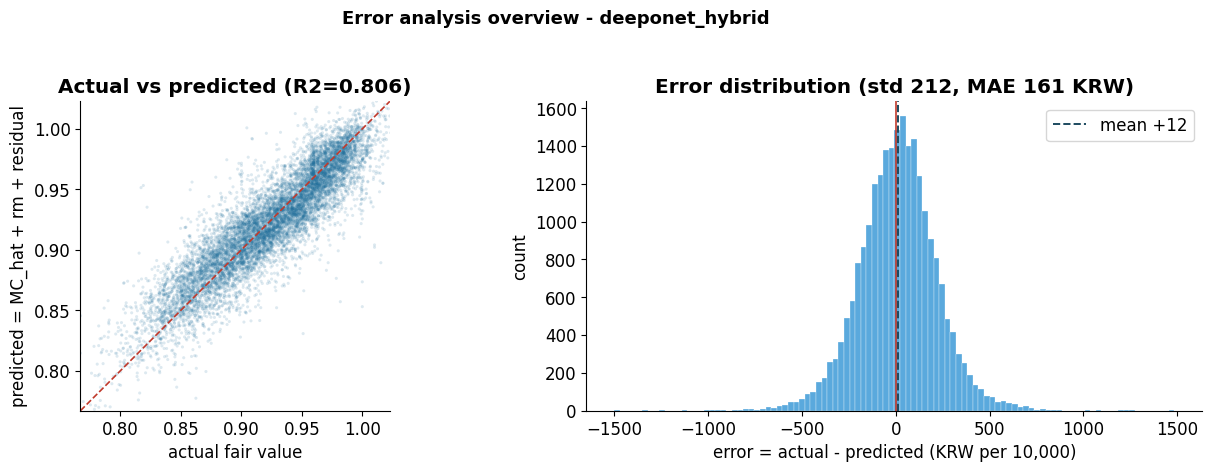

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
s = A.sample(min(10000, len(A)), random_state=0)
lim = [A.y_true.quantile(.002), A.y_true.quantile(.998)]
ax[0].scatter(s.y_true, s.y_pred, s=5, alpha=.15, color=BLU, edgecolors="none")
ax[0].plot(lim, lim, "--", color=RED, lw=1.2); ax[0].set_xlim(lim); ax[0].set_ylim(lim); ax[0].set_aspect("equal")
ax[0].set_xlabel("actual fair value"); ax[0].set_ylabel("predicted = MC_hat + rm + residual")
ax[0].set_title(f"Actual vs predicted (R2={r2(A):.3f})")
e = A.err * FACE
ax[1].hist(e.clip(-1500, 1500), bins=100, color="#5aa9dd", edgecolor="white", lw=.2)
ax[1].axvline(0, color=RED, lw=1.2); ax[1].axvline(e.mean(), color=DK, lw=1.4, ls="--", label=f"mean {e.mean():+.0f}")
ax[1].set_xlabel("error = actual - predicted (KRW per 10,000)"); ax[1].set_ylabel("count")
ax[1].set_title(f"Error distribution (std {e.std():.0f}, MAE {e.abs().mean():.0f} KRW)"); ax[1].legend()
fig.suptitle(f"Error analysis overview - {best}", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG/"err_overview.png"); plt.show()

## 2. Stage-2 residual fit & heteroskedasticity

`residual = fair - MC_hat - recent_margin` 이 stage-2 가 맞춰야 할 대상. 얼마나 예측되는가 + 오차가 마진 크기에 비례하는가.

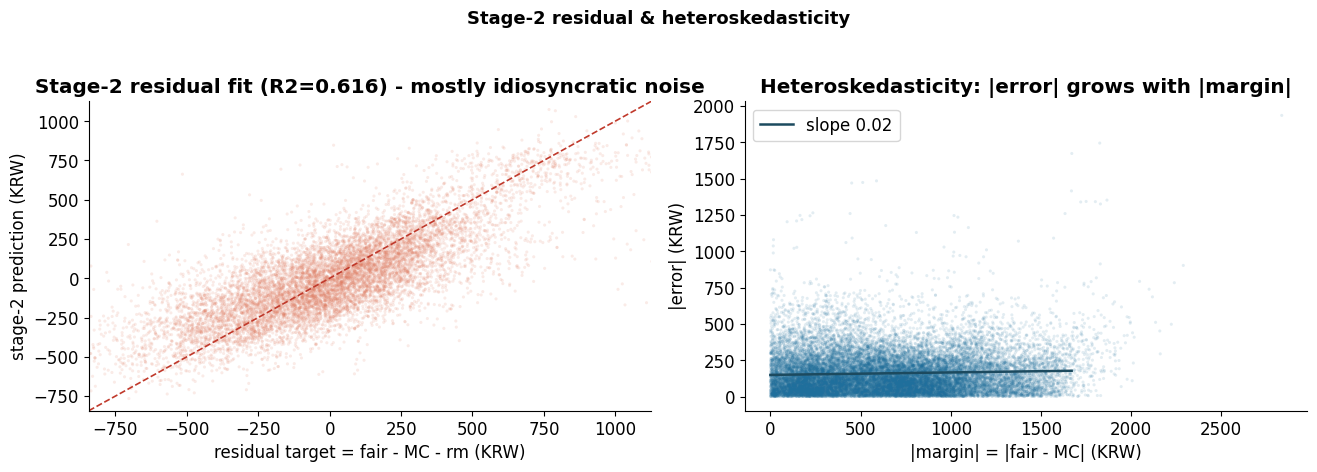

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
s = A.sample(min(10000, len(A)), random_state=0)
rl = [A.resid_true.quantile(.005)*FACE, A.resid_true.quantile(.995)*FACE]
ax[0].scatter(s.resid_true*FACE, s.resid_pred*FACE, s=5, alpha=.15, color=ORG, edgecolors="none")
ax[0].plot(rl, rl, "--", color=RED, lw=1.2); ax[0].set_xlim(rl); ax[0].set_ylim(rl)
ax[0].set_xlabel("residual target = fair - MC - rm (KRW)"); ax[0].set_ylabel("stage-2 prediction (KRW)")
ax[0].set_title(f"Stage-2 residual fit (R2={residR2:.3f}) - mostly idiosyncratic noise")
ax[1].scatter(A.margin.abs()*FACE, A.err.abs()*FACE, s=5, alpha=.12, color=BLU, edgecolors="none")
b, a0 = np.polyfit(A.margin.abs()*FACE, A.err.abs()*FACE, 1); xs = np.array([0, A.margin.abs().quantile(.99)*FACE])
ax[1].plot(xs, a0 + b*xs, "-", color=DK, lw=1.8, label=f"slope {b:.2f}")
ax[1].set_xlabel("|margin| = |fair - MC| (KRW)"); ax[1].set_ylabel("|error| (KRW)")
ax[1].set_title("Heteroskedasticity: |error| grows with |margin|"); ax[1].legend()
fig.suptitle("Stage-2 residual & heteroskedasticity", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG/"err_residual.png"); plt.show()

## 3. By issue year — R2, MAE, bias (time non-stationarity)

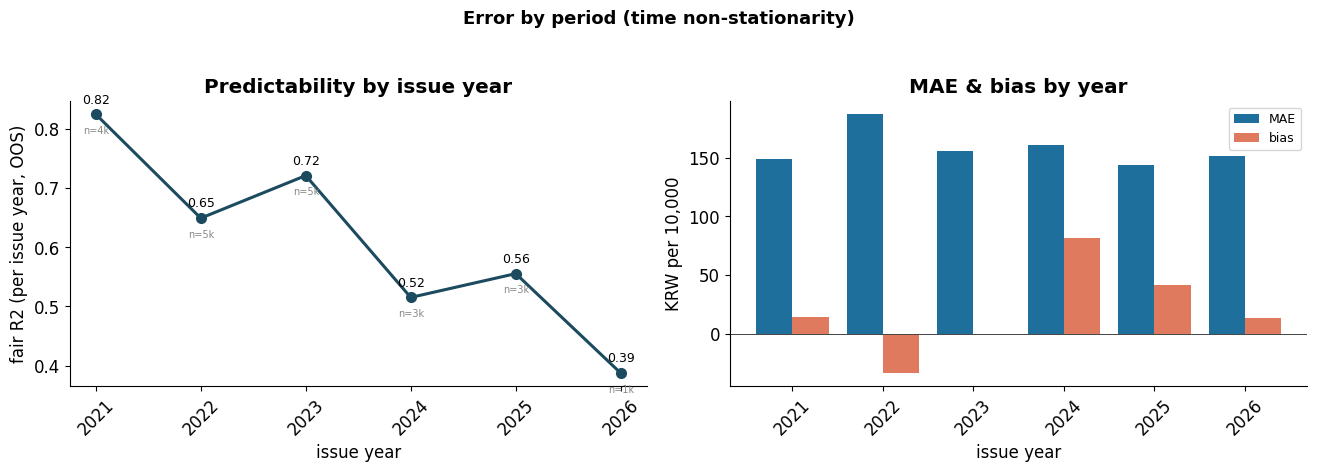

 year    n    R2   MAE  bias
 2021 4574 0.825 149.0  14.0
 2022 5705 0.649 187.0 -34.0
 2023 5432 0.721 156.0  -0.0
 2024 3101 0.515 161.0  81.0
 2025 3535 0.555 144.0  41.0
 2026 1169 0.388 151.0  13.0


In [5]:
yrs = sorted(A.year.unique())
gy = pd.DataFrame({"year": yrs,
    "n": [int((A.year == y).sum()) for y in yrs],
    "R2": [r2(A[A.year == y]) for y in yrs],
    "MAE": [A[A.year == y].err.abs().mean()*FACE for y in yrs],
    "bias": [A[A.year == y].err.mean()*FACE for y in yrs]})
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
ax[0].plot(gy.year.astype(str), gy.R2, "o-", color=DK, lw=2.2, ms=7)
for x, rr, nn in zip(range(len(gy)), gy.R2, gy.n):
    ax[0].annotate(f"{rr:.2f}", (x, rr), fontsize=9, ha="center", xytext=(0, 8), textcoords="offset points")
    ax[0].annotate(f"n={nn//1000}k", (x, rr), fontsize=7, color="#888", ha="center", xytext=(0, -14), textcoords="offset points")
ax[0].set_ylabel("fair R2 (per issue year, OOS)"); ax[0].set_xlabel("issue year"); ax[0].set_title("Predictability by issue year"); ax[0].tick_params(axis="x", rotation=45)
xw = np.arange(len(yrs)); w = 0.4
ax[1].bar(xw - w/2, gy.MAE, w, color=BLU, label="MAE"); ax[1].bar(xw + w/2, gy.bias, w, color=ORG, label="bias")
ax[1].axhline(0, color="#444", lw=.7); ax[1].set_xticks(xw); ax[1].set_xticklabels(gy.year.astype(str), rotation=45)
ax[1].set_ylabel("KRW per 10,000"); ax[1].set_xlabel("issue year"); ax[1].set_title("MAE & bias by year"); ax[1].legend(fontsize=9)
fig.suptitle("Error by period (time non-stationarity)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG/"err_by_period.png"); plt.show()
print(gy.assign(R2=gy.R2.round(3), MAE=gy.MAE.round(0), bias=gy.bias.round(0)).to_string(index=False))

## 4. By issuer — R2 and MAE (issuers with n>=200)

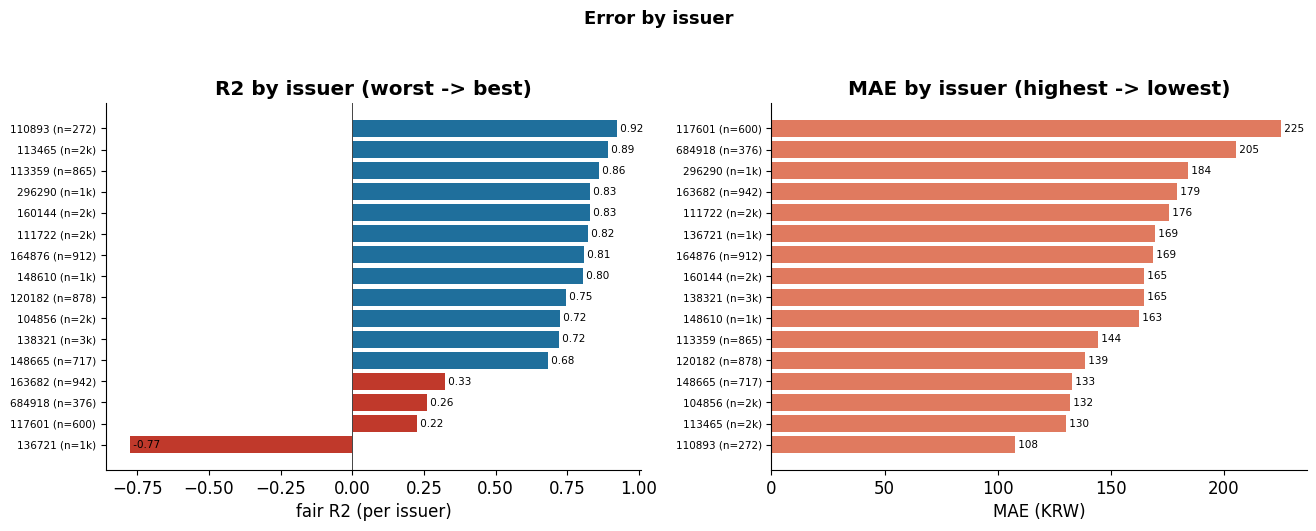

issuer    n     R2   MAE
136721 1421 -0.775 169.0
117601  600  0.224 225.0
684918  376  0.262 205.0
163682  942  0.325 179.0
148665  717  0.683 133.0
138321 3177  0.722 165.0
104856 2300  0.725 132.0
120182  878  0.746 139.0
148610 1011  0.804 163.0
164876  912  0.807 169.0
111722 2836  0.824 176.0
160144 2742  0.829 165.0
296290 1786  0.830 184.0
113359  865  0.859 144.0
113465 2421  0.894 130.0
110893  272  0.923 108.0


In [6]:
iss = [i for i in A.issuer.dropna().unique()]
rows = [(i, int((A.issuer == i).sum()), r2(A[A.issuer == i]), A[A.issuer == i].err.abs().mean()*FACE) for i in iss]
gi = pd.DataFrame(rows, columns=["issuer", "n", "R2", "MAE"]).query("n>=200")
gr = gi.sort_values("R2"); gm = gi.sort_values("MAE", ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(13.333, 5.4))
y1 = np.arange(len(gr))
ax[0].barh(y1, gr.R2, color=[RED if v < 0.55 else BLU for v in gr.R2]); ax[0].axvline(0, color="#444", lw=.7)
ax[0].set_yticks(y1); ax[0].set_yticklabels([f"{i} (n={n//1000}k)" if n >= 1000 else f"{i} (n={n})" for i, n in zip(gr.issuer, gr.n)], fontsize=7.5)
for i, v in enumerate(gr.R2): ax[0].text(v, i, f" {v:.2f}", va="center", fontsize=7.5)
ax[0].set_xlabel("fair R2 (per issuer)"); ax[0].set_title("R2 by issuer (worst -> best)")
y2 = np.arange(len(gm))
ax[1].barh(y2, gm.MAE, color=ORG); ax[1].set_yticks(y2)
ax[1].set_yticklabels([f"{i} (n={n//1000}k)" if n >= 1000 else f"{i} (n={n})" for i, n in zip(gm.issuer, gm.n)], fontsize=7.5); ax[1].invert_yaxis()
for i, v in enumerate(gm.MAE): ax[1].text(v, i, f" {v:.0f}", va="center", fontsize=7.5)
ax[1].set_xlabel("MAE (KRW)"); ax[1].set_title("MAE by issuer (highest -> lowest)")
fig.suptitle("Error by issuer", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG/"err_by_issuer.png"); plt.show()
print(gr.assign(R2=gr.R2.round(3), MAE=gr.MAE.round(0)).to_string(index=False))

## 5. By price segment · structure · volatility

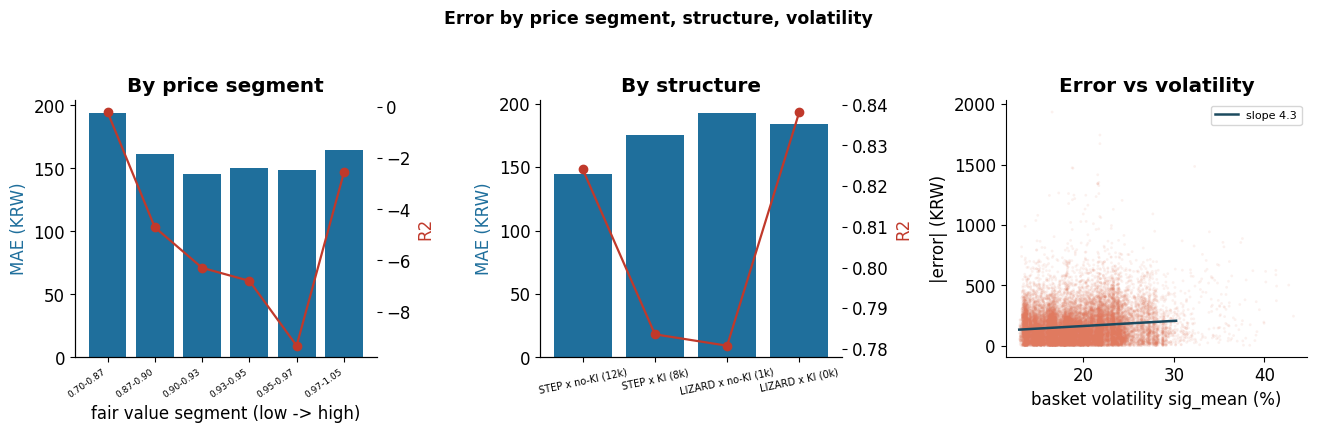

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.4))
seg = pd.qcut(A.y_true, 6); xs = np.arange(6)
mae_s = [A[seg == c].err.abs().mean()*FACE for c in seg.cat.categories]; r2_s = [r2(A[seg == c]) for c in seg.cat.categories]
ax[0].bar(xs, mae_s, color=BLU); ax2 = ax[0].twinx(); ax2.plot(xs, r2_s, "o-", color=RED, lw=1.6)
ax[0].set_xticks(xs); ax[0].set_xticklabels([f"{i.left:.2f}-{i.right:.2f}" for i in seg.cat.categories], rotation=35, fontsize=6.5, ha="right")
ax[0].set_ylabel("MAE (KRW)", color=BLU); ax2.set_ylabel("R2", color=RED); ax[0].set_xlabel("fair value segment (low -> high)"); ax[0].set_title("By price segment")
gt = A.groupby("struct").agg(n=("err", "size")).reset_index().sort_values("n", ascending=False)
gt["R2"] = [r2(A[A.struct == st]) for st in gt.struct]; gt["MAE"] = [A[A.struct == st].err.abs().mean()*FACE for st in gt.struct]
xt = np.arange(len(gt))
ax[1].bar(xt, gt.MAE, color=BLU); ax3 = ax[1].twinx(); ax3.plot(xt, gt.R2, "o-", color=RED, lw=1.6)
ax[1].set_xticks(xt); ax[1].set_xticklabels([f"{s} ({n//1000}k)" for s, n in zip(gt.struct, gt.n)], fontsize=7)
ax[1].set_ylabel("MAE (KRW)", color=BLU); ax3.set_ylabel("R2", color=RED); ax[1].set_title("By structure"); ax[1].tick_params(axis="x", rotation=12)
ax[2].scatter(A.sig_mean*100, A.err.abs()*FACE, s=4, alpha=.1, color=ORG, edgecolors="none")
b, a0 = np.polyfit(A.sig_mean*100, A.err.abs()*FACE, 1); xv = np.array([A.sig_mean.min()*100, A.sig_mean.quantile(.99)*100])
ax[2].plot(xv, a0 + b*xv, "-", color=DK, lw=1.8, label=f"slope {b:.1f}")
ax[2].set_xlabel("basket volatility sig_mean (%)"); ax[2].set_ylabel("|error| (KRW)"); ax[2].set_title("Error vs volatility"); ax[2].legend(fontsize=8)
fig.suptitle("Error by price segment, structure, volatility", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG/"err_by_segment.png"); plt.show()

## 6. 결론 — stage-2 오차의 원인

1. **본질적 특이 잡음**: stage-2 residual R² 가 낮음 — recent_margin 회수 후 남는 `fair−MC−rm` 은 발행사·시점별 idiosyncratic 마진이라 예측 한계(그림 2 좌).
2. **비정상성(기간)**: 발행연도별 R² 가 최근 하락 — 시장 마진 레짐 변화로 과거 학습이 외삽 실패(그림 3).
3. **발행사 이질성**: 일부 발행사에서 R² 낮고 MAE 큼 — 고유 마진 관행을 특성이 못 담음(그림 4).
4. **이분산성/구조**: |오차|가 마진·변동성·KI/저가 구간에서 증가(그림 2 우, 5).
→ **개선**: 인과 마진 드라이버(발행사·시장 프리미엄·IV−HV) + 레짐 적응/최근 가중 + 이분산 대응(분위수·robust loss) + 발행사별 모델링.